MODULE 1.0: Load Data and Ground Truth Labels

In [1]:
# --- Module 1.0: Load Data and Ground Truth Labels ---

import pandas as pd
import numpy as np
import os

# Load training and validation spectra (each column is one spectrum)
training_spectra_df = pd.read_csv("C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Training Data_30 Conditions.csv", header=None)
validation_spectra_df = pd.read_csv("C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Test Data_Hydrostatic_7 conditions.csv", header=None)

# Load ground truth temperature and pressure labels for each condition
training_labels_df = pd.read_csv("C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\NEW_T and P Ground Truth Tags_Training Data.csv", header=None)
validation_labels_df = pd.read_csv("C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\NEW_T and P Ground Truth Tags_Test Data_Hydrostatic.csv", header=None)

# Extract mean T and P values from the label files
T_training_labels = training_labels_df[0].values  # Temperature labels (K)
P_training_labels = training_labels_df[2].values  # Pressure labels (GPa)
T_validating_labels = validation_labels_df[0].values
P_validating_labels = validation_labels_df[2].values

MODULE 1.1: Preprocess Spectra

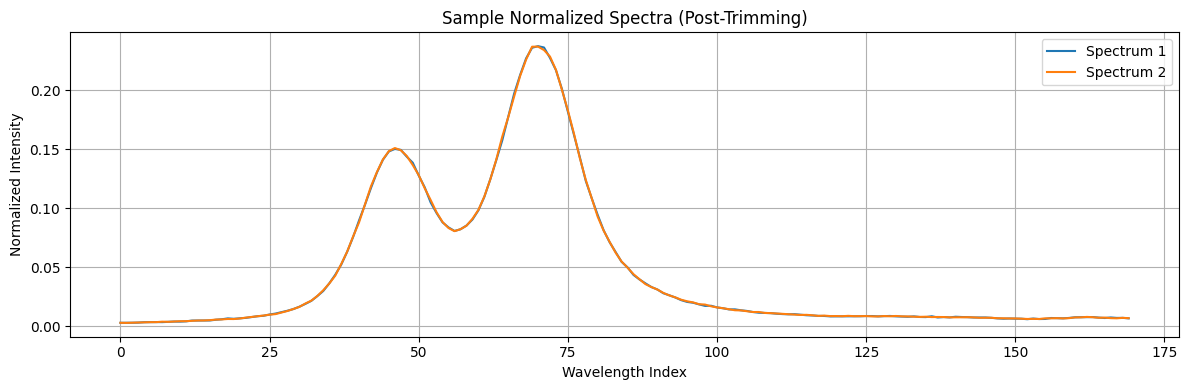

In [2]:
# --- Module 1.1: Preprocess Spectra ---

# Choose the spectral region:

# Trim rows 212–1167 (690-740) - "full spectral range, but trimmed"
# trim_range = slice(212, 1168)

# Trim rows 212–381 (690-700) - "R-lines region"
trim_range = slice(212, 382)

# Trim rows 382–1167 (700-740) - "N-lines, vibronic sidebands, and U-band"
# trim_range = slice(382, 1168)

trimmed_training = training_spectra_df.values[trim_range, :]
trimmed_validation = validation_spectra_df.values[trim_range, :]

# Normalize each column (spectrum)
norm_training = trimmed_training / np.linalg.norm(trimmed_training, axis=0)
norm_validation = trimmed_validation / np.linalg.norm(trimmed_validation, axis=0)

# Transpose to shape [samples, features]
transposed_training_spectra = norm_training.T
transposed_validation_spectra = norm_validation.T

# Visualize a few sample spectra after trimming and normalization (change i value in: "for i in range(i)")
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i in range(2):
    plt.plot(transposed_training_spectra[i], label=f"Spectrum {i+1}")
plt.title("Sample Normalized Spectra (Post-Trimming)")
plt.xlabel("Wavelength Index")
plt.ylabel("Normalized Intensity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

MODULE 1.2: Manual Binning of Ground Truth Labels

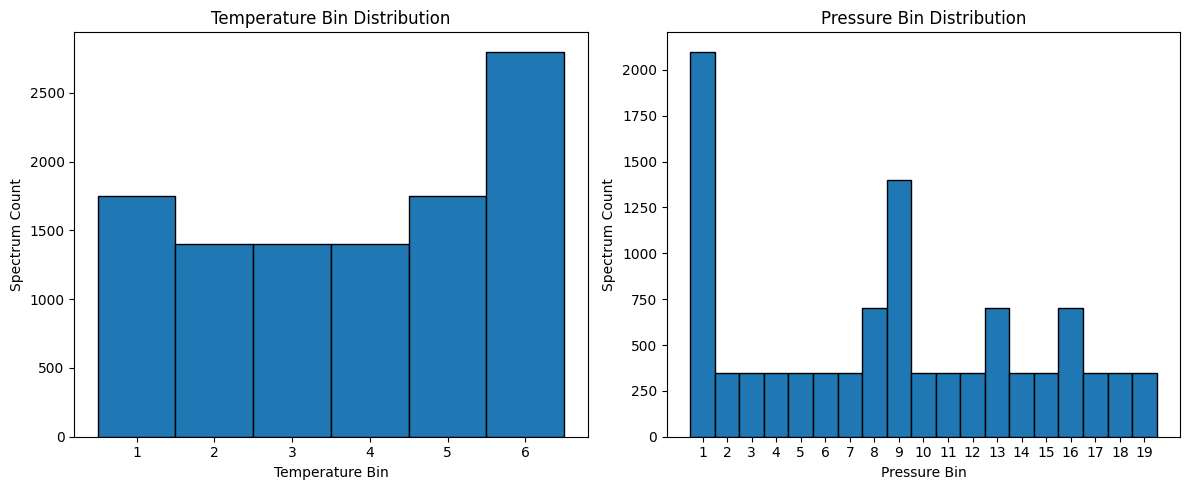


--- Condition-to-Bin Mapping (Training Only) ---
Index  Temp (K)   Pres (GPa)   T Bin  P Bin 
0      298.9      0.00         1      1
1      298.6      2.44         1      8
2      298.5      2.61         1      10
3      298.5      4.47         1      16
4      298.6      4.49         1      16
5      323.5      0.00         2      1
6      323.4      2.51         2      9
7      323.4      3.92         2      13
8      323.4      4.97         2      19
9      347.8      0.00         3      1
10     347.6      2.52         3      9
11     347.6      3.58         3      11
12     347.6      4.76         3      18
13     374.0      0.00         4      1
14     374.0      2.21         4      6
15     374.1      2.53         4      9
16     374.0      4.61         4      17
17     398.7      0.00         5      1
18     398.7      1.43         5      4
19     398.8      2.54         5      9
20     398.9      3.75         5      12
21     398.7      4.34         5      15
22     424.0   

In [3]:
# --- Module 1.2: Manual Binning of Ground Truth Labels ---

import numpy as np
import matplotlib.pyplot as plt

# Define T bin edges 
# Edges placed between the well-defined isotherms. 
temperature_bin_edges = np.array([286.1, 311.0, 335.5, 360.8, 386.4, 411.5, 436.7])

# Define P bin edges
# Edges placed between discrete P conditions, such that each discrete P condition is its own P class; ...
# however, bin together P conditions that are statistically indiscernible; ...
# i.e., conditions that differ by 0.02 GPa or less (the maximum P ground truth uncertainty). 
pressure_bin_edges = np.array([-0.10, 0.38, 1.00, 1.33, 1.77, 2.16, 2.22, 2.34, 2.47, 2.56, 3.09, 3.66, 3.83, 4.00, 4.20, 4.40, 4.50, 4.68, 4.86, 5.06])

pressure_bins_count = len(pressure_bin_edges) - 1  # Total pressure bins = edges - 1

# Manual binning functions
def manual_T_bins(data):
    return np.digitize(data, bins=temperature_bin_edges, right=False)

def manual_P_bins(data):
    return np.digitize(data, bins=pressure_bin_edges, right=False)

# Apply binning to condition-level labels
temperature_bins = manual_T_bins(T_training_labels)
pressure_bins = manual_P_bins(P_training_labels)

spectra_per_condition = 350  # Number of spectra per condition

# Expand binned labels to match per-spectrum labels
y_train_T = np.repeat(temperature_bins, spectra_per_condition)
y_train_P = np.repeat(pressure_bins, spectra_per_condition)

# --- Visualize Binned Distributions ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
#plt.hist(y_train_T, bins=np.arange(1, len(temperature_bin_edges)) - 0.5, edgecolor='black')
plt.hist(y_train_T, bins=np.arange(1, len(temperature_bin_edges) + 1) - 0.5, edgecolor='black')
plt.title("Temperature Bin Distribution")
plt.xlabel("Temperature Bin")
plt.ylabel("Spectrum Count")
plt.xticks(range(1, len(temperature_bin_edges)))

plt.subplot(1, 2, 2)
plt.hist(y_train_P, bins=np.arange(1, pressure_bins_count + 2) - 0.5, edgecolor='black')
plt.title("Pressure Bin Distribution")
plt.xlabel("Pressure Bin")
plt.ylabel("Spectrum Count")
plt.xticks(range(1, pressure_bins_count + 1))

plt.tight_layout()
plt.show()

# --- Print Condition-to-Bin Assignments ---
print("\n--- Condition-to-Bin Mapping (Training Only) ---")
print(f"{'Index':<6} {'Temp (K)':<10} {'Pres (GPa)':<12} {'T Bin':<6} {'P Bin':<6}")
for i in range(len(T_training_labels)):
    print(f"{i:<6} {T_training_labels[i]:<10.1f} {P_training_labels[i]:<12.2f} {temperature_bins[i]:<6} {pressure_bins[i]}")


EXPORT: Histograms of T and P Class Balance

# Export Histograms of T and P Class Balance

export_path = r"C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Polishing LDA\\Code and chekcpoints\\FINAL LDA_EXPORTS"

# Count number of spectra per T/P bin
t_bin_counts = pd.Series(temperature_bins).value_counts().sort_index()
p_bin_counts = pd.Series(pressure_bins).value_counts().sort_index()

# Turn counts into dataframes
t_df = t_bin_counts.rename_axis("T Bin").reset_index(name="T Count")
p_df = p_bin_counts.rename_axis("P Bin").reset_index(name="P Count")

# Pad shorter side so both have the same number of rows
max_len = max(len(t_df), len(p_df))
t_df = t_df.reindex(range(max_len))
p_df = p_df.reindex(range(max_len))

# Combine and export
bin_stats_df = pd.concat([t_df, p_df], axis=1)
file_path = os.path.join(export_path, "Histograms of T and P Class Balance.csv")
bin_stats_df.to_csv(file_path, index=False)
print(f"T and P bin stats exported to:\n{file_path}")

MODULE 1.3: Visualizing Binning

(-0.2, 5.17)

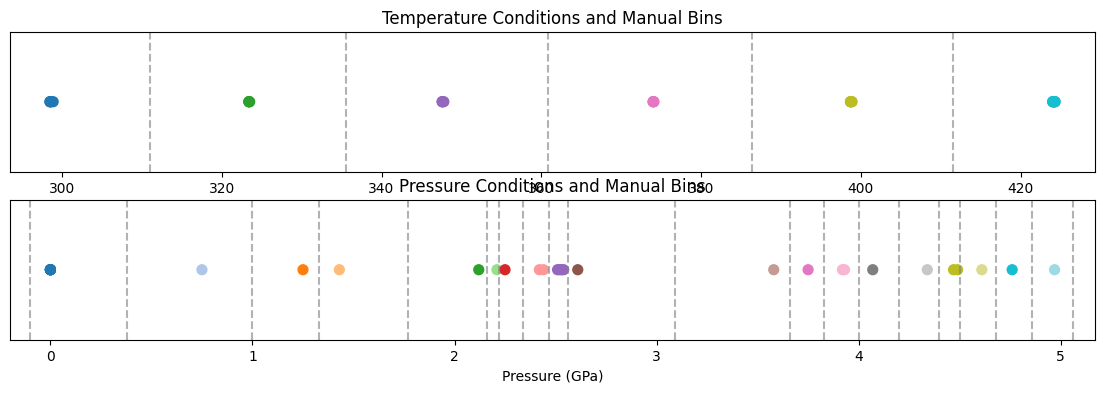

In [4]:
# --- Module 1.3: Visualizing Binning

import matplotlib.pyplot as plt

# --- Manual Bin Edges
temperature_bin_edges = np.array([286.1, 311.0, 335.5, 360.8, 386.4, 411.5, 436.7])
pressure_bin_edges = np.array([-0.10, 0.38, 1.00, 1.33, 1.77, 2.16, 2.22, 2.34, 2.47, 2.56, 3.09, 3.66, 3.83, 4.00, 4.20, 4.40, 4.50, 4.68, 4.86, 5.06])

# Sort conditions for visual clarity
sorted_T_indices = np.argsort(T_training_labels)
sorted_P_indices = np.argsort(P_training_labels)

plt.figure(figsize=(14, 4))

# --- Temperature Binning Visualization (Trimmed to actual range) ---
plt.subplot(2, 1, 1)
plt.scatter(T_training_labels[sorted_T_indices], np.zeros_like(T_training_labels), 
            c=temperature_bins[sorted_T_indices], cmap='tab10', s=50)
for edge in temperature_bin_edges:
    plt.axvline(edge, color='gray', linestyle='--', alpha=0.6)
plt.title("Temperature Conditions and Manual Bins")
plt.xlabel("Temperature (K)")
plt.yticks([])
T_min = T_training_labels.min()
T_max = T_training_labels.max()
plt.xlim(T_min - 5, T_max + 5)

# --- Pressure Binning Visualization (Color by Bin) ---
plt.subplot(2, 1, 2)

# Use bin index for color coding
plt.scatter(P_training_labels[sorted_P_indices], 
            np.zeros_like(P_training_labels), 
            c=pressure_bins[sorted_P_indices], 
            cmap='tab20',  
            s=50)

# Draw manual bin edges
for edge in pressure_bin_edges:
    plt.axvline(edge, color='gray', linestyle='--', alpha=0.6)

plt.title("Pressure Conditions and Manual Bins")
plt.xlabel("Pressure (GPa)")
plt.yticks([])
P_min = P_training_labels.min()
P_max = P_training_labels.max()
plt.xlim(P_min - 0.2, P_max + 0.2)

MODULE 2.0: Compute All LDA Components (T and P)

In [5]:
# --- Module 2.0: Compute All LDA Components (T and P) ---

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Standardize training spectra
scaler = StandardScaler()
scaled_training_spectra = scaler.fit_transform(transposed_training_spectra)

# Train LDA models
LDA_T = LinearDiscriminantAnalysis()
LDA_T.fit(scaled_training_spectra, y_train_T)

LDA_P = LinearDiscriminantAnalysis()
LDA_P.fit(scaled_training_spectra, y_train_P)

# Project training data onto all LD components
LD_T_projection = LDA_T.transform(scaled_training_spectra)
LD_P_projection = LDA_P.transform(scaled_training_spectra)

MODULE 2.1: Scree Plots, LD1/LD2 Weights, and Explained Variance Tables

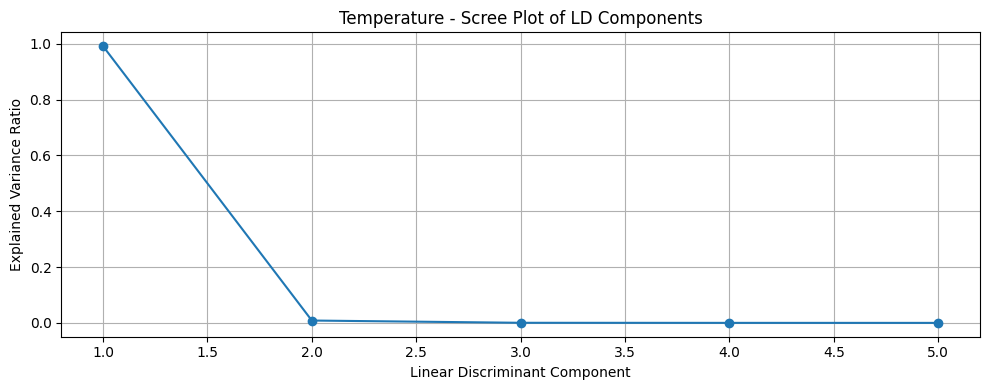


🔎 Temperature - Explained Variance by Component:


,Component,Explained Variance Ratio
0,LD1,0.9911
1,LD2,0.0085
2,LD3,0.0004
3,LD4,0.0001
4,LD5,0.0000


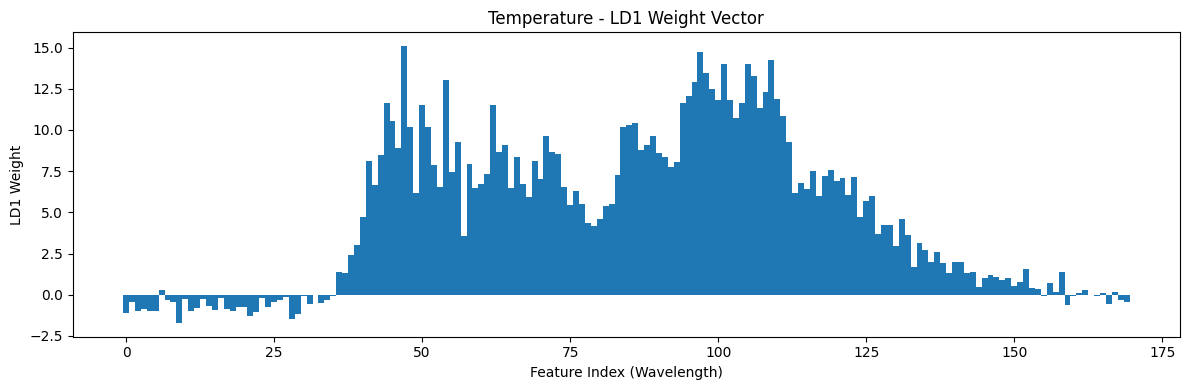

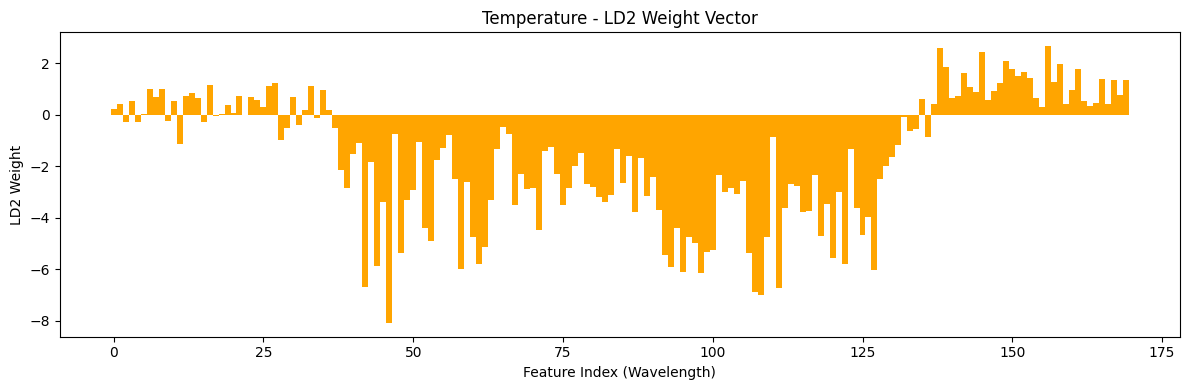

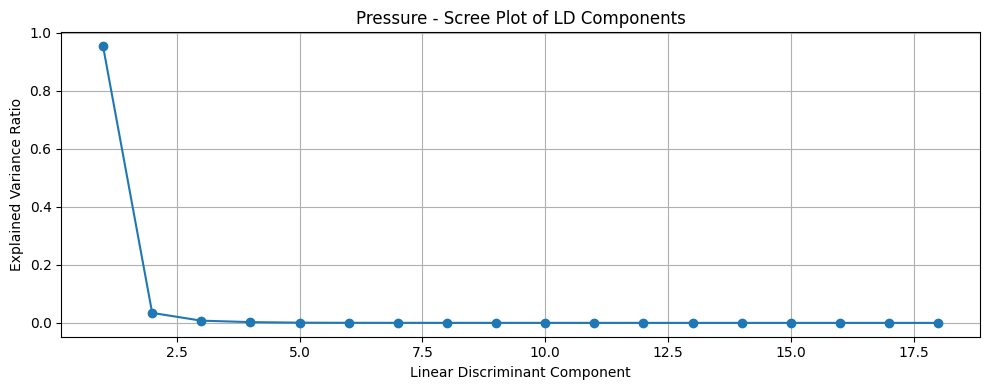


🔎 Pressure - Explained Variance by Component:


,Component,Explained Variance Ratio
0,LD1,0.9536
1,LD2,0.0344
2,LD3,0.0077
3,LD4,0.0027
4,LD5,0.0007
5,LD6,0.0003
6,LD7,0.0002
7,LD8,0.0001
8,LD9,0.0001
9,LD10,0.0001


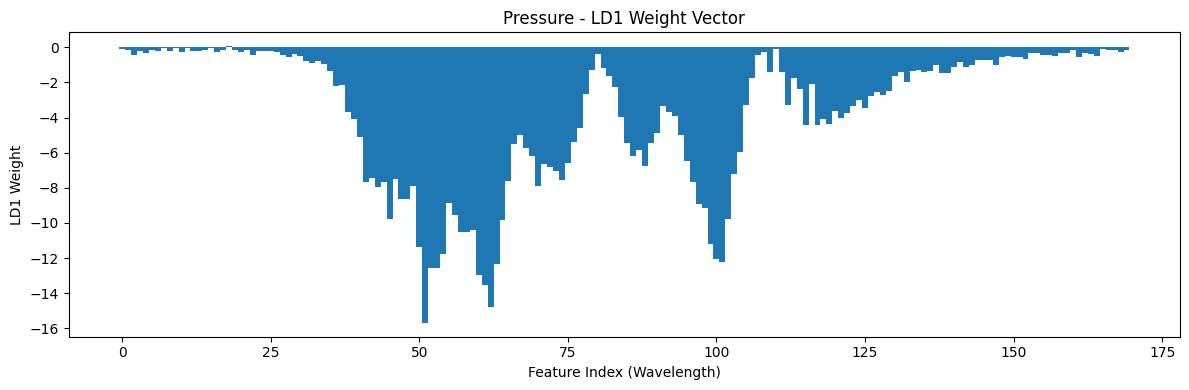

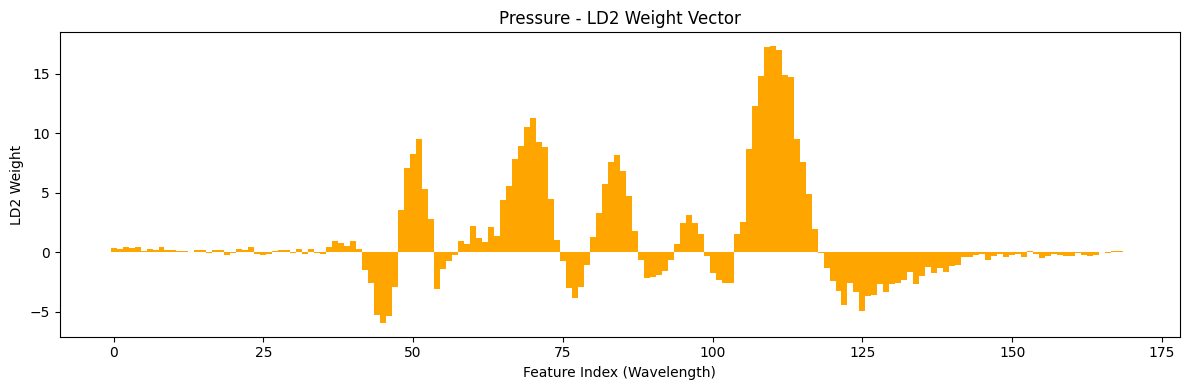

In [6]:
# --- Module 2.1: Scree Plots, LD1/LD2 Weights, and Explained Variance Tables ---

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_scree_and_weights(lda_model, title_prefix):
    explained_variance = lda_model.explained_variance_ratio_
    n_components = len(explained_variance)
    component_labels = [f"LD{i+1}" for i in range(n_components)]

    # --- Scree Plot ---
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, n_components + 1), explained_variance, marker='o')
    plt.title(f"{title_prefix} - Scree Plot of LD Components")
    plt.xlabel("Linear Discriminant Component")
    plt.ylabel("Explained Variance Ratio")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Explained Variance Table ---
    variance_df = pd.DataFrame({
        "Component": component_labels,
        "Explained Variance Ratio": explained_variance
    })
    print(f"\n🔎 {title_prefix} - Explained Variance by Component:")
    display(variance_df.round(4))

    # --- LD1 Weights ---
    ld1_weights = lda_model.scalings_[:, 0]
    plt.figure(figsize=(12, 4))
    plt.bar(np.arange(len(ld1_weights)), ld1_weights, width=1.0)
    plt.title(f"{title_prefix} - LD1 Weight Vector")
    plt.xlabel("Feature Index (Wavelength)")
    plt.ylabel("LD1 Weight")
    plt.tight_layout()
    plt.show()

    # --- LD2 Weights (if available) ---
    if lda_model.scalings_.shape[1] >= 2:
        ld2_weights = lda_model.scalings_[:, 1]
        plt.figure(figsize=(12, 4))
        plt.bar(np.arange(len(ld2_weights)), ld2_weights, width=1.0, color='orange')
        plt.title(f"{title_prefix} - LD2 Weight Vector")
        plt.xlabel("Feature Index (Wavelength)")
        plt.ylabel("LD2 Weight")
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ {title_prefix}: Only LD1 was available (no LD2).")

# --- Run for both LDA models ---
plot_scree_and_weights(LDA_T, "Temperature")
plot_scree_and_weights(LDA_P, "Pressure")


EXPORT: Scree Plots and Vector Loadings 

import os
import pandas as pd
import numpy as np


# --- Export LDA Results to CSV ---

def export_lda_results(lda_model, prefix, export_dir):
    explained_variance = lda_model.explained_variance_ratio_
    component_labels = [f"LD{i+1}" for i in range(len(explained_variance))]
    
    # Explained Variance Table
    variance_df = pd.DataFrame({
        "Component": component_labels,
        "Explained Variance Ratio": explained_variance
    })
    variance_df.to_csv(os.path.join(export_dir, f"explained_variance_{prefix}.csv"), index=False)

    # LD1 Weights
    ld1_weights = lda_model.scalings_[:, 0]
    ld1_df = pd.DataFrame({"Feature Index": np.arange(len(ld1_weights)), "LD1 Weight": ld1_weights})
    ld1_df.to_csv(os.path.join(export_dir, f"ld1_weights_{prefix}.csv"), index=False)

    # LD2 Weights (if available)
    if lda_model.scalings_.shape[1] >= 2:
        ld2_weights = lda_model.scalings_[:, 1]
        ld2_df = pd.DataFrame({"Feature Index": np.arange(len(ld2_weights)), "LD2 Weight": ld2_weights})
        ld2_df.to_csv(os.path.join(export_dir, f"ld2_weights_{prefix}.csv"), index=False)

# Ensure export directory exists
export_dir = r"C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Polishing LDA\\Code and chekcpoints\\FINAL LDA_EXPORTS\\700-740"
os.makedirs(export_dir, exist_ok=True)

# Export for both models
export_lda_results(LDA_T, "temperature", export_dir)
export_lda_results(LDA_P, "pressure", export_dir)

print("✅ LDA outputs exported as CSV files.")


MODULE 2.2: LDA Quality Checks & Diagnostics

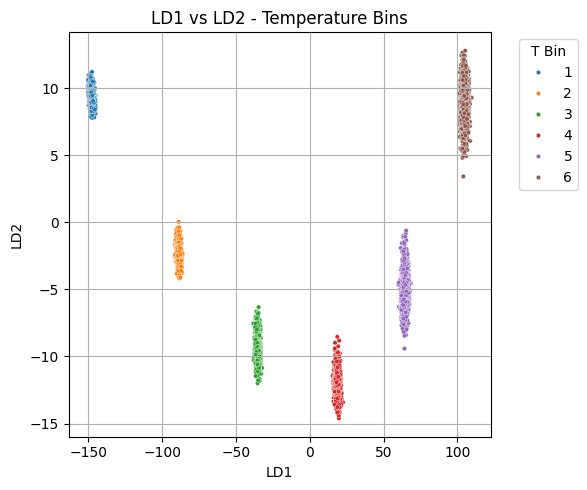

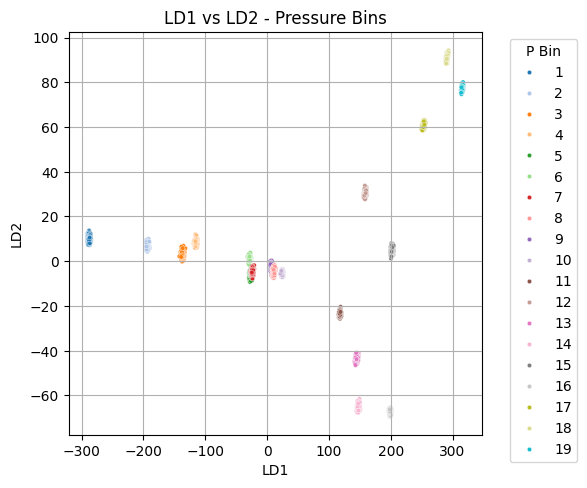

In [7]:
# --- Module 2.2: LDA Quality Checks & Diagnostics ---

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

# CONFUSION MATRIX???

# LD1 vs LD2 Scatterplots (Class Separation) 
if LD_T_projection.shape[1] >= 2:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=LD_T_projection[:, 0], y=LD_T_projection[:, 1],
                    hue=y_train_T, palette='tab10', s=10, legend='full')
    plt.title("LD1 vs LD2 - Temperature Bins")
    plt.xlabel("LD1")
    plt.ylabel("LD2")
    plt.grid(True)
    plt.legend(title="T Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

if LD_P_projection.shape[1] >= 2:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=LD_P_projection[:, 0], y=LD_P_projection[:, 1],
                    hue=y_train_P, palette='tab20', s=10, legend='full')
    plt.title("LD1 vs LD2 - Pressure Bins")
    plt.xlabel("LD1")
    plt.ylabel("LD2")
    plt.grid(True)
    plt.legend(title="P Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

EXPORT: Export LD1 vs LD2 Projection Data

# --- Export LD1 vs LD2 Projection Data as CSV: non-segregated bin format ---

import os

export_dir = r"C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Polishing LDA\\Code and chekcpoints\\FINAL LDA_EXPORTS"

if LD_T_projection.shape[1] >= 2:
    ld_t_df = pd.DataFrame({
        "LD1": LD_T_projection[:, 0],
        "LD2": LD_T_projection[:, 1],
        "T Bin": y_train_T
    })
    ld_t_df.to_csv(os.path.join(export_dir, "ld1 vs ld2_temperature_690 to 740.csv"), index=False)
    print("✅ Exported: ld1 vs ld2_temperature.csv")

if LD_P_projection.shape[1] >= 2:
    ld_p_df = pd.DataFrame({
        "LD1": LD_P_projection[:, 0],
        "LD2": LD_P_projection[:, 1],
        "P Bin": y_train_P
    })
    ld_p_df.to_csv(os.path.join(export_dir, "ld1 vs ld2_pressure_690 to 740.csv"), index=False)
    print("✅ Exported: ld1 vs ld2_pressure.csv")


# --- Export LD1 vs LD2 Projection Data as CSV: segregated bin format ---

import os
import pandas as pd

export_dir = r"C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Polishing LDA\\Code and chekcpoints\\FINAL LDA_EXPORTS"

def export_ld_pairs_wide(proj, bins, prefix, outname):
    if proj.shape[1] < 2:
        print(f"⚠️ Not enough LD components for {prefix}. Skipping.")
        return

    df = pd.DataFrame({
        "Bin": bins,
        "LD1": proj[:, 0],
        "LD2": proj[:, 1],
    })
    # create a row index within each bin so pivot lines up rows
    df["row"] = df.groupby("Bin").cumcount()

    wide = df.pivot(index="row", columns="Bin", values=["LD1", "LD2"])

    # interleave columns as: LD1(bin0), LD2(bin0), LD1(bin1), LD2(bin1), ...
    bin_order = sorted(df["Bin"].unique())
    cols = [(comp, b) for b in bin_order for comp in ["LD1", "LD2"]]
    wide = wide.reindex(columns=pd.MultiIndex.from_tuples(cols))

    # flatten column names
    wide.columns = [f"{prefix} {comp} (Bin {b})" for comp, b in wide.columns]

    wide.to_csv(os.path.join(export_dir, outname), index=False)
    print(f"✅ Exported: {outname}")

# Temperature
export_ld_pairs_wide(
    LD_T_projection, y_train_T,
    prefix="T",
    outname="ld1 vs ld2_temperature_690 to 740_segregated bins.csv",
)

# Pressure
export_ld_pairs_wide(
    LD_P_projection, y_train_P,
    prefix="P",
    outname="ld1 vs ld2_pressure_690 to 740_segregated bins.csv",
)

MODULE 2.3: LD1 Mean ± Std vs T and P (3D Scatter Plots with Error Bars)

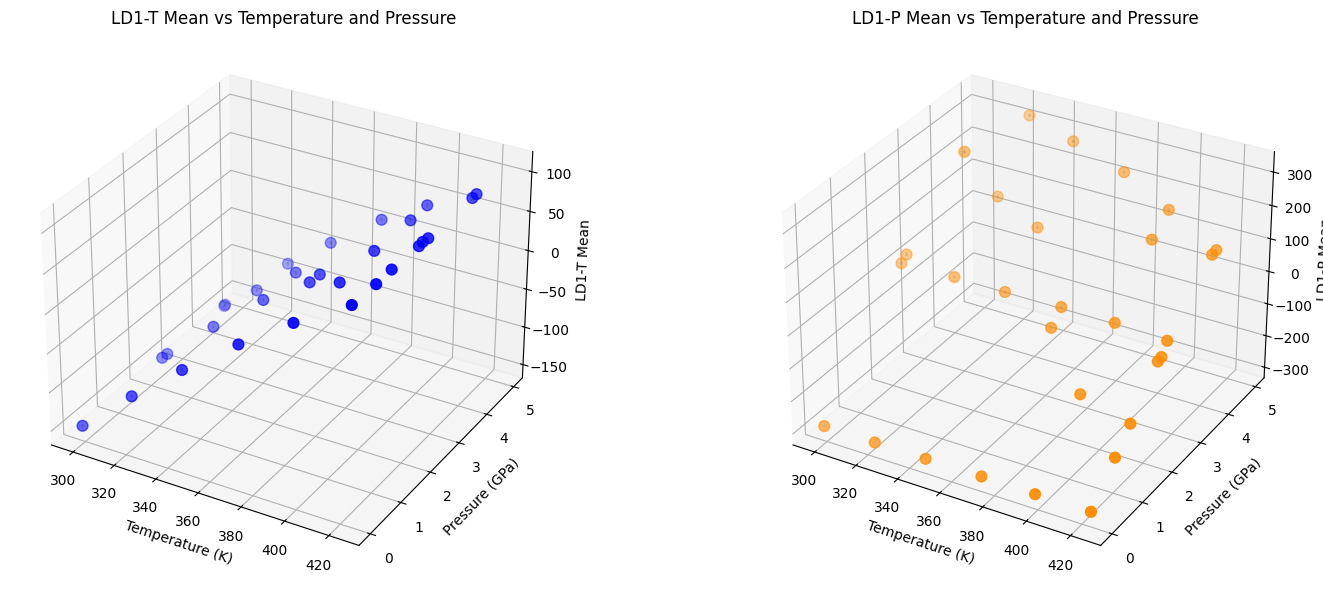

In [8]:
# --- Module 2.3: LD1 Mean ± Std vs T and P (3D Scatter Plots with Error Bars) ---

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# --- Compute LD1 statistics per condition ---
LD1_T_means, LD1_T_stds, LD1_P_means, LD1_P_stds = [], [], [], []

for i in range(len(T_training_labels)):
    start = i * spectra_per_condition
    end = start + spectra_per_condition

    ld1_t_vals = LD_T_projection[start:end, 0]
    ld1_p_vals = LD_P_projection[start:end, 0]

    LD1_T_means.append(np.mean(ld1_t_vals))
    LD1_T_stds.append(np.std(ld1_t_vals))

    LD1_P_means.append(np.mean(ld1_p_vals))
    LD1_P_stds.append(np.std(ld1_p_vals))

LD1_T_means = np.array(LD1_T_means)
LD1_T_stds = np.array(LD1_T_stds)
LD1_P_means = np.array(LD1_P_means)
LD1_P_stds = np.array(LD1_P_stds)

# --- Plot side-by-side 3D plots ---
fig = plt.figure(figsize=(16, 6))

# --- LD1-T Mean Plot ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(T_training_labels, P_training_labels, LD1_T_means, color='blue', s=60)
ax1.set_title("LD1-T Mean vs Temperature and Pressure")
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Pressure (GPa)")
ax1.set_zlabel("LD1-T Mean")

# Error bars
for t, p, z, err in zip(T_training_labels, P_training_labels, LD1_T_means, LD1_T_stds):
    ax1.plot([t, t], [p, p], [z - err, z + err], color='gray', alpha=0.4)

# --- LD1-P Mean Plot ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(T_training_labels, P_training_labels, LD1_P_means, color='darkorange', s=60)
ax2.set_title("LD1-P Mean vs Temperature and Pressure")
ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel("Pressure (GPa)")
ax2.set_zlabel("LD1-P Mean")

# Error bars
for t, p, z, err in zip(T_training_labels, P_training_labels, LD1_P_means, LD1_P_stds):
    ax2.plot([t, t], [p, p], [z - err, z + err], color='gray', alpha=0.4)

plt.tight_layout()
plt.show()


MODULE 2.4: Fitting LD1-T and LD1-P Surfaces

✅ LD1-T fit (cubic):
LD1-T = -147.0334 + 2.4381*T + -0.002571*T^2 + -0.000007*T^3
R² = 1.0000

✅ LD1-P fit (linear):
LD1-P = -282.5811 + 113.8415*P
R² = 0.9931


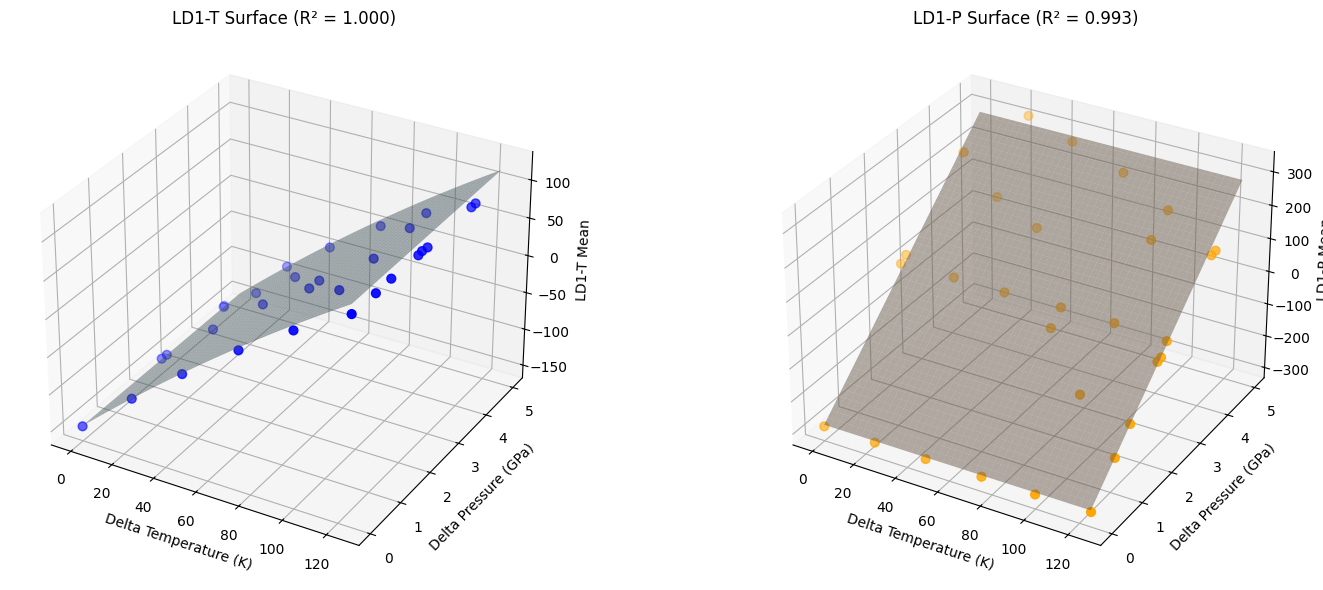

In [9]:
# --- Module 2.4: Surface Fits, Stats, Plots, and Long CSV Export ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from numpy.polynomial.polynomial import Polynomial
from sklearn.metrics import r2_score

# --- Use deltas for fitting and plotting in Module 2.4 ---
dP = P_training_labels - 0.0001  # GPa
dT = T_training_labels - 298.9   # K

# --- Setup meshgrid ---
T_range = np.arange(0.00, 125 + 1e-6, 1.0)
P_range = np.arange(0.00, 5.00 + 1e-6, 0.01)
T_grid, P_grid = np.meshgrid(T_range, P_range, indexing='ij')  # shape (T_len, P_len)

# --- Fit LD1-T (CUBIC in T) ---
p_model = Polynomial.fit(dT, LD1_T_means, deg=3).convert()
coeffs_T = p_model.coef
LD1_T_pred = p_model(dT)
r2_T = r2_score(LD1_T_means, LD1_T_pred)

# --- Fit LD1-P (Linear in P) ---
model_P = LinearRegression().fit(dP.reshape(-1, 1), LD1_P_means)
LD1_P_pred = model_P.predict(dP.reshape(-1, 1))
r2_P = r2_score(LD1_P_means, LD1_P_pred)

# --- Evaluate on meshgrid ---
LD1_T_surface = coeffs_T[0] + coeffs_T[1]*T_grid + coeffs_T[2]*T_grid**2
LD1_P_surface = model_P.intercept_ + model_P.coef_[0]*P_grid

# --- Convert surfaces to long-format DataFrames ---
LD1_T_long = pd.DataFrame({
    "Delta Temperature (K)": T_grid.ravel(),
    "Delta Pressure (GPa)": P_grid.ravel(),
    "LD1-T Value": LD1_T_surface.ravel()
})
LD1_P_long = pd.DataFrame({
    "Delta Temperature (K)": T_grid.ravel(),
    "Delta Pressure (GPa)": P_grid.ravel(),
    "LD1-P Value": LD1_P_surface.ravel()
})

# --- Display models and R² stats ---
print("✅ LD1-T fit (cubic):")
print(f"LD1-T = {coeffs_T[0]:.4f} + {coeffs_T[1]:.4f}*T + {coeffs_T[2]:.6f}*T^2 + {coeffs_T[3]:.6f}*T^3")
print(f"R² = {r2_T:.4f}")

print("\n✅ LD1-P fit (linear):")
print(f"LD1-P = {model_P.intercept_:.4f} + {model_P.coef_[0]:.4f}*P")
print(f"R² = {r2_P:.4f}")

# --- Visualization ---
fig = plt.figure(figsize=(16, 6))

# LD1-T
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(dT, dP, LD1_T_means, color='blue', label='Data', s=40)
ax1.plot_surface(T_grid, P_grid, LD1_T_surface, alpha=0.5, color='lightblue')
ax1.set_title(f"LD1-T Surface (R² = {r2_T:.3f})")
ax1.set_xlabel("Delta Temperature (K)")
ax1.set_ylabel("Delta Pressure (GPa)")
ax1.set_zlabel("LD1-T Mean")

# LD1-P
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(dT, dP, LD1_P_means, color='orange', label='Data', s=40)
ax2.plot_surface(T_grid, P_grid, LD1_P_surface, alpha=0.5, color='peachpuff')
ax2.set_title(f"LD1-P Surface (R² = {r2_P:.3f})")
ax2.set_xlabel("Delta Temperature (K)")
ax2.set_ylabel("Delta Pressure (GPa)")
ax2.set_zlabel("LD1-P Mean")

plt.tight_layout()
plt.show()

EXPORT: LD1-T and LD1-P scatters and surfaces

# --- Export LD1-T and LD1-P scatters and surfaces ---

# --- Setup paths and meshgrid (inclusive) ---
export_dir = Path(r"C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Polishing LDA\\Code and chekcpoints\\FINAL LDA_EXPORTS")
export_dir.mkdir(parents=True, exist_ok=True)

# --- Export long-format CSVs ---
LD1_T_long.to_csv(export_dir / "LD1-T_Quadratic Surface.csv", index=False)
LD1_P_long.to_csv(export_dir / "LD1-P_Linear Surface.csv", index=False)

# --- Export original scatter data ---
scatter_T_df = pd.DataFrame({
    "Temperature (K)": T_training_labels,
    "Pressure (GPa)": P_training_labels,
    "LD1-T Mean": LD1_T_means,
    "LD1-T Std": LD1_T_stds
})
scatter_T_df.to_csv(export_dir / "LD1-T_Scatter.csv", index=False)

scatter_P_df = pd.DataFrame({
    "Temperature (K)": T_training_labels,
    "Pressure (GPa)": P_training_labels,
    "LD1-P Mean": LD1_P_means,
    "LD1-P Std": LD1_P_stds
})
scatter_P_df.to_csv(export_dir / "LD1-P_Scatter.csv", index=False)

MODULE 2.5: Justification for Cubic (LD1-T) and Linear (LD1-P) Regressions


📈 Regression Diagnostics for Temperature (X) vs LD1 Means (Y):


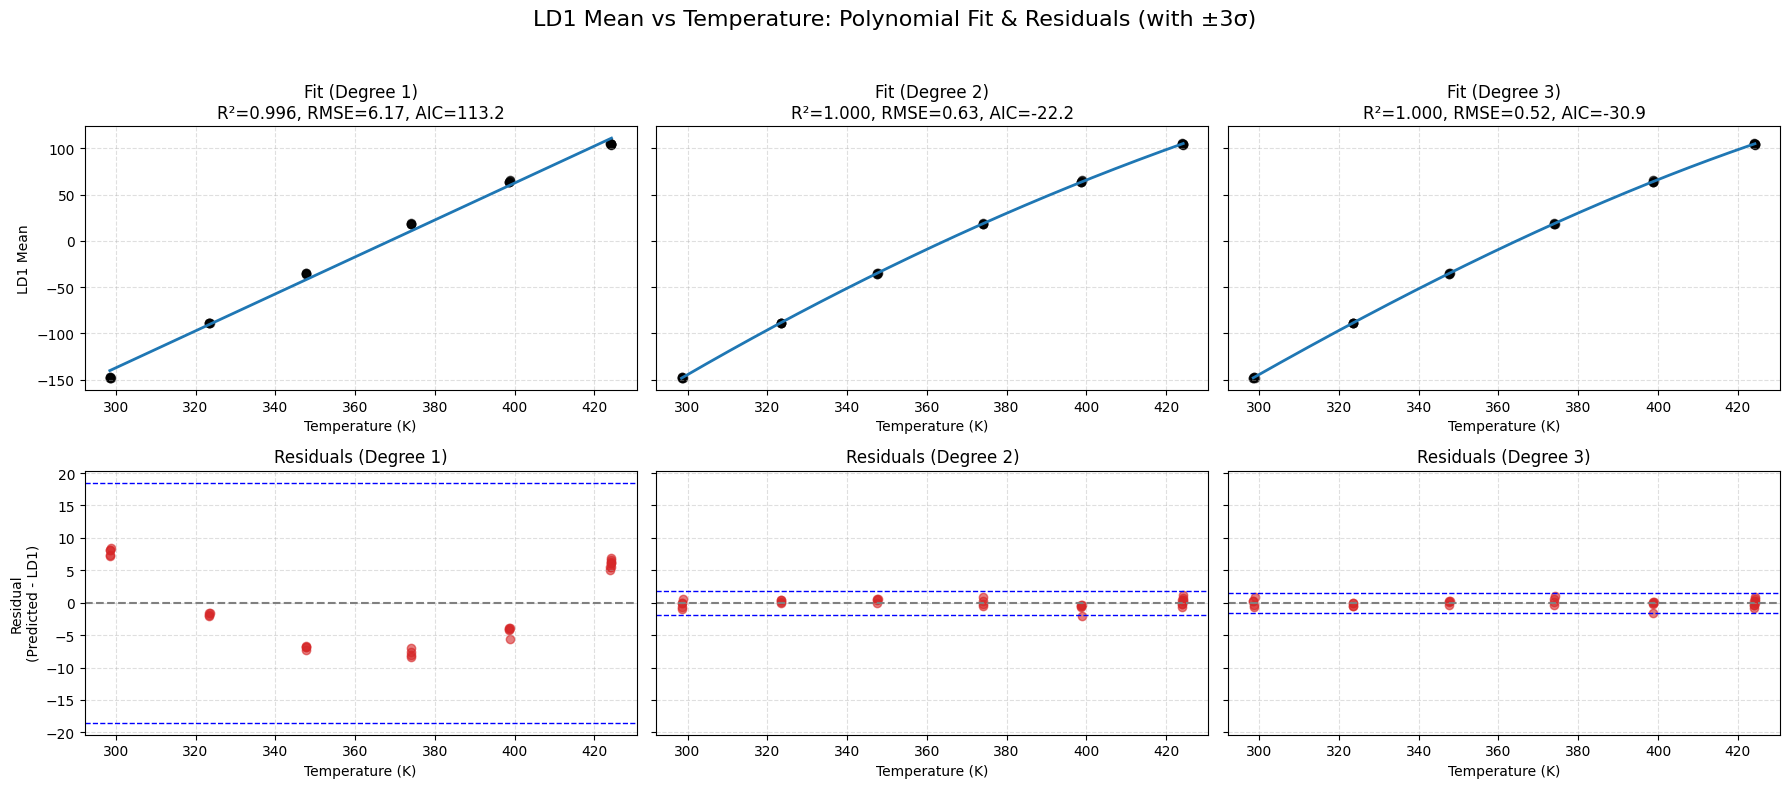


📈 Regression Diagnostics for Pressure (X) vs LD1 Means (Y):


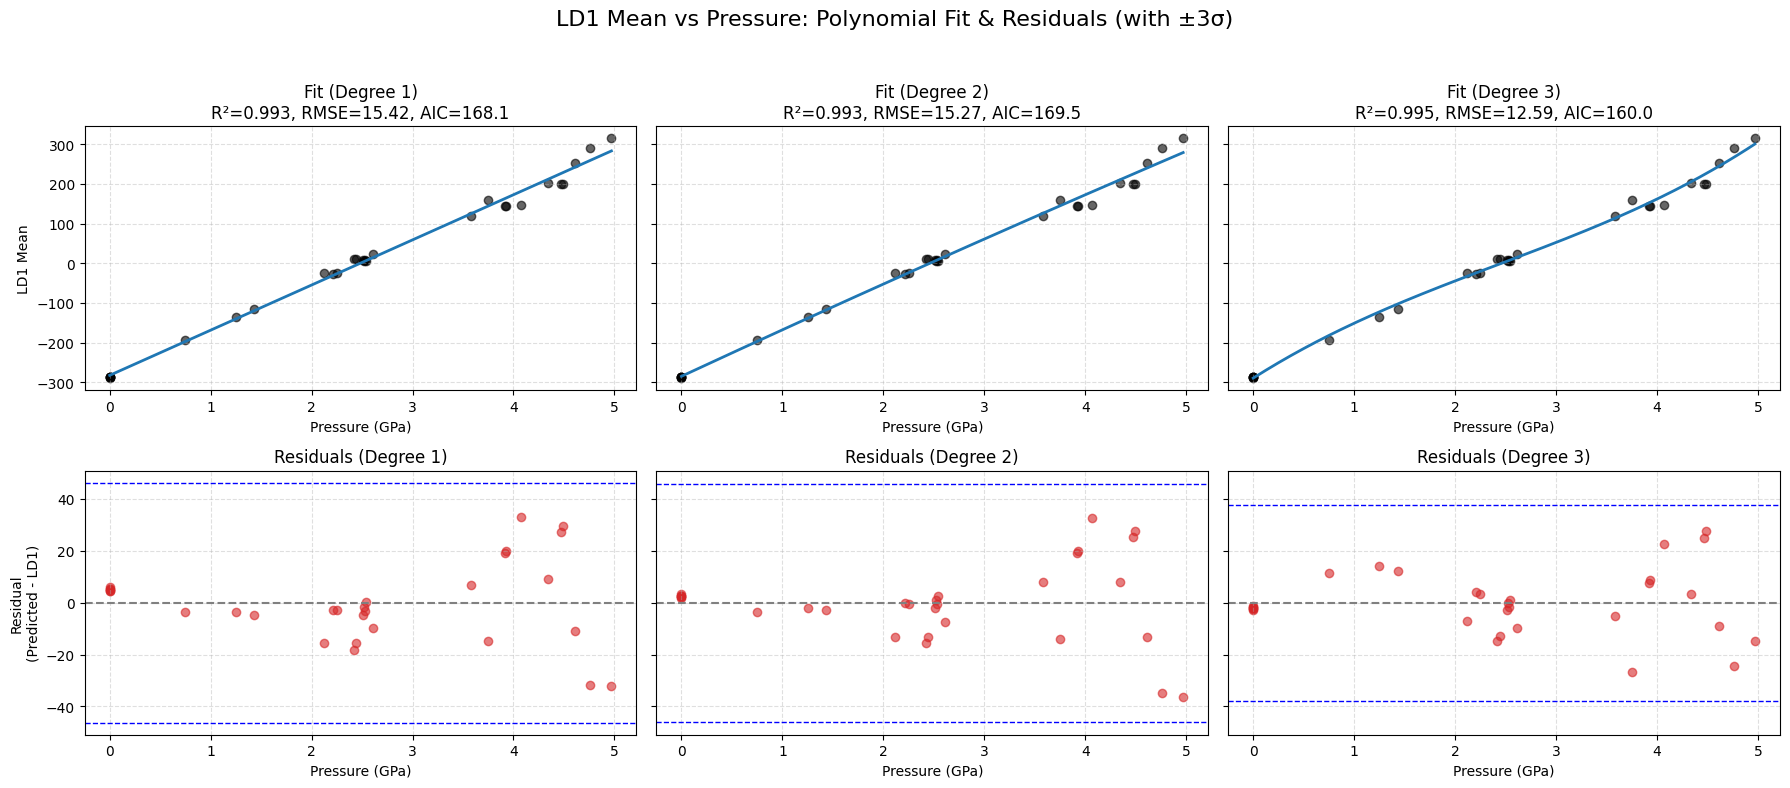

In [10]:
# --- Module 2.5: Justification for Cubic (LD1-T) and Linear (LD1-P) Regressions ---

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

def run_regressions(ld1_means, true_labels, label, unit):
    print(f"\n📈 Regression Diagnostics for {label} (X) vs LD1 Means (Y):")
    n = len(true_labels)

    # Sort by true labels for smooth curve plotting
    sorted_idx = np.argsort(true_labels)
    x_sorted = true_labels[sorted_idx]
    y_sorted = ld1_means[sorted_idx]

    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey='row')

    for i, degree in enumerate([1, 2, 3]):
        poly = PolynomialFeatures(degree)
        X_poly = poly.fit_transform(true_labels.reshape(-1, 1))
        model = LinearRegression().fit(X_poly, ld1_means)
        preds = model.predict(X_poly)

        mse = mean_squared_error(ld1_means, preds)
        rmse = np.sqrt(mse)
        r2 = r2_score(ld1_means, preds)
        k = X_poly.shape[1]
        aic = n * np.log(mse) + 2 * k

        # Smooth prediction curve
        x_fit = np.linspace(true_labels.min(), true_labels.max(), 200).reshape(-1, 1)
        y_fit = model.predict(poly.transform(x_fit))

        # --- Fit plot ---
        ax_fit = axes[0, i]
        ax_fit.scatter(true_labels, ld1_means, color='black', alpha=0.6, label='Data')
        ax_fit.plot(x_fit, y_fit, color='tab:blue', linewidth=2)
        ax_fit.set_title(f"Fit (Degree {degree})\nR²={r2:.3f}, RMSE={rmse:.2f}, AIC={aic:.1f}")
        ax_fit.set_xlabel(f"{label} ({unit})")
        if i == 0:
            ax_fit.set_ylabel("LD1 Mean")
        ax_fit.grid(True, linestyle='--', alpha=0.4)

        # --- Residual plot with ±3σ ---
        residuals = preds - ld1_means
        sigma = np.std(residuals)

        ax_resid = axes[1, i]
        ax_resid.scatter(true_labels, residuals, color='tab:red', alpha=0.6)
        ax_resid.axhline(0, color='gray', linestyle='--')
        ax_resid.axhline(3 * sigma, color='blue', linestyle='--', linewidth=1, label='+3σ')
        ax_resid.axhline(-3 * sigma, color='blue', linestyle='--', linewidth=1, label='-3σ')
        ax_resid.set_title(f"Residuals (Degree {degree})")
        ax_resid.set_xlabel(f"{label} ({unit})")
        if i == 0:
            ax_resid.set_ylabel("Residual\n(Predicted - LD1)")
        ax_resid.grid(True, linestyle='--', alpha=0.4)

    fig.suptitle(f"LD1 Mean vs {label}: Polynomial Fit & Residuals (with ±3σ)", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# --- Run for both properties ---
run_regressions(LD1_T_means, T_training_labels, "Temperature", "K")
run_regressions(LD1_P_means, P_training_labels, "Pressure", "GPa")

MODULE 2.6a: Checking for confounding: Plot LD1-T vs P and LD1-P vs T

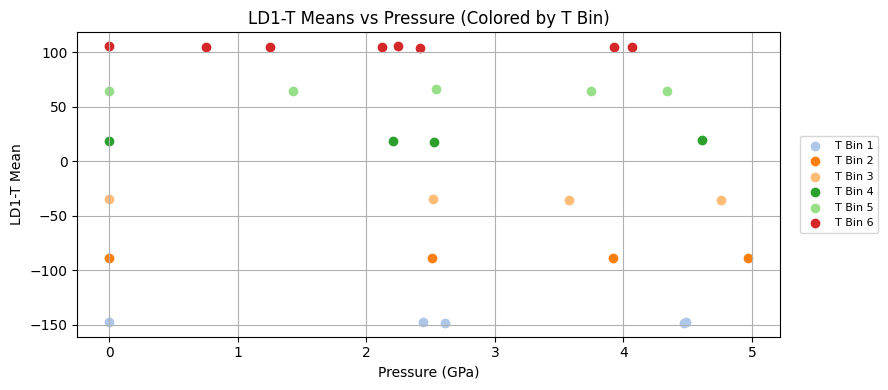

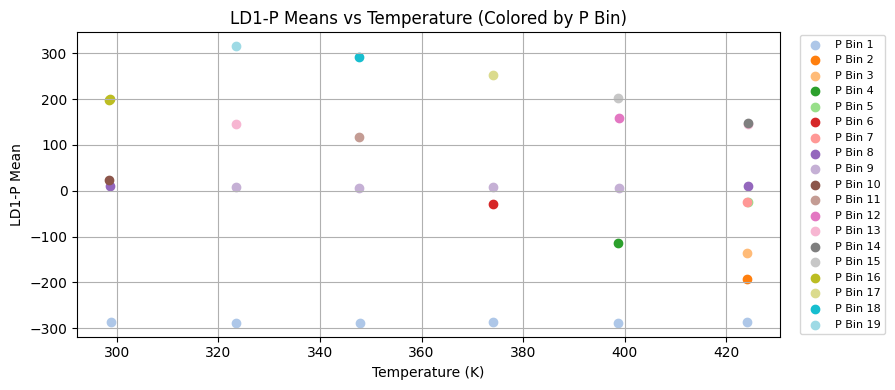

In [11]:
# --- Module 2.6a: Checking for confounding: Plot LD1-T vs P and LD1-P vs T (Colored by True Bin Assignments) ---
# LD1-T SHOULD NOT exhibit any dependence on P, and LD1-P SHOULD NOT exhibit any dependence on T. 

import matplotlib.pyplot as plt
import numpy as np

# Use existing bin assignments
# temperature_bins = manual_T_bins(T_training_labels)
# pressure_bins = manual_P_bins(P_training_labels)

# Use a colormap with many distinct colors
cmap = plt.get_cmap("tab20")

# --- LD1-T Means vs Pressure ---
plt.figure(figsize=(8, 4))
for bin_id in np.unique(temperature_bins):
    mask = temperature_bins == bin_id
    plt.scatter(P_training_labels[mask], LD1_T_means[mask],
                color=cmap(bin_id % 20), label=f"T Bin {bin_id}")
plt.xlabel("Pressure (GPa)")
plt.ylabel("LD1-T Mean")
plt.title("LD1-T Means vs Pressure (Colored by T Bin)")
plt.grid(True)
plt.tight_layout()
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()

# --- LD1-P Means vs Temperature ---
plt.figure(figsize=(8, 4))
for bin_id in np.unique(pressure_bins):
    mask = pressure_bins == bin_id
    plt.scatter(T_training_labels[mask], LD1_P_means[mask],
                color=cmap(bin_id % 20), label=f"P Bin {bin_id}")
plt.xlabel("Temperature (K)")
plt.ylabel("LD1-P Mean")
plt.title("LD1-P Means vs Temperature (Colored by P Bin)")
plt.grid(True)
plt.tight_layout()
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()

MODULE 2.6b: Checking for confounding: Computing the angle (cosine similarity) between LD1-T and LD1-P

Cosine similarity between LD1-T and LD1-P: -0.856174
⚠️ LD1-T and LD1-P are not orthogonal.
Angle between LD1-T and LD1-P: 148.89°


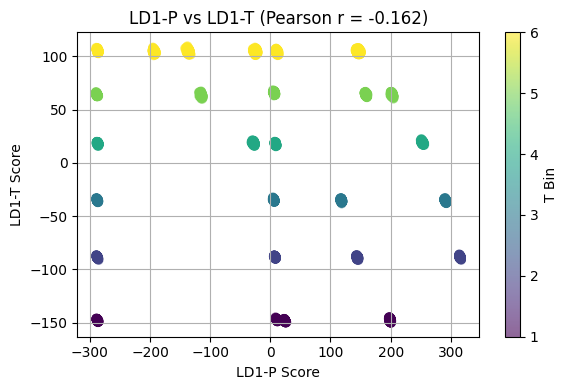

In [12]:
# --- Module 2.6b: Checking for confounding: Computing the angle (cosine similarity) between LD1-T and LD1-P ---

from numpy.linalg import norm
import numpy as np

# Extract LD1 vectors (first column of scalings matrix)
LD1_T = LDA_T.scalings_[:, 0]
LD1_P = LDA_P.scalings_[:, 0]

# Compute cosine similarity
cosine_sim = np.dot(LD1_T, LD1_P) / (norm(LD1_T) * norm(LD1_P))

print(f"Cosine similarity between LD1-T and LD1-P: {cosine_sim:.6f}")

if np.isclose(cosine_sim, 0, atol=1e-2):
    print("✅ LD1-T and LD1-P are nearly orthogonal.")
else:
    print("⚠️ LD1-T and LD1-P are not orthogonal.")

# --- Compute angle between LD1-T and LD1-P in degrees ---
angle_deg = np.degrees(np.arccos(np.clip(cosine_sim, -1.0, 1.0)))
print(f"Angle between LD1-T and LD1-P: {angle_deg:.2f}°")


# --- Scatter Plot of LD1-T vs LD1-P Projections ---

import matplotlib.pyplot as plt

# Extract LD1 scores
ld1_T_scores = LD_T_projection[:, 0]
ld1_P_scores = LD_P_projection[:, 0]

# Pearson correlation
r = np.corrcoef(ld1_P_scores, ld1_T_scores)[0, 1]

# Scatter (colored by T bin)
plt.figure(figsize=(6, 4))
sc = plt.scatter(ld1_P_scores, ld1_T_scores, alpha=0.6, c=y_train_T, cmap="viridis")
plt.xlabel("LD1-P Score")
plt.ylabel("LD1-T Score")
plt.title(f"LD1-P vs LD1-T (Pearson r = {r:.3f})")
plt.grid(True)

# Colorbar for bins
cbar = plt.colorbar(sc)
cbar.set_label("T Bin")

plt.tight_layout()
plt.show()

NOTES:

Cosine similarity = −0.798 → angle ≈ 142.95°
The two LD1 loading vectors (feature-space directions) are strongly aligned but sign-flipped. Because LDA axes have arbitrary sign, flipping one vector would give |cos|≈0.80 (≈37°). Either way, they’re not orthogonal, meaning T and P rely on largely overlapping spectral directions → potential feature-level confounding.

Pearson r (scores) = −0.165
Across your actual samples, LD1-T scores and LD1-P scores are only weakly (slightly negative) correlated. So at the sample level the two discriminants don’t move together much—good news for practical separability.

Reconciling both:
It’s possible for loadings to be non-orthogonal while scores are nearly uncorrelated because the data covariance / bin structure can make projections behave independently even if the directions in feature space overlap.

EXPORT: LD1-T vs LD1-P scatter for Pearson r analysis

# === Export LD1-P (x) vs LD1-T (y) for Origin ===
import numpy as np
import pandas as pd
import matplotlib as mpl
import os

# --- Define export folder ---
export_dir = r"C:\Users\NP.5066655\OneDrive - UAM\Escritorio\Polishing LDA\Code and chekcpoints\FINAL LDA_EXPORTS\700-740"
os.makedirs(export_dir, exist_ok=True)

# --- Match your scatter variables ---
x_P = np.asarray(ld1_P_scores).ravel()   # X-axis (LD1-P)
y_T = np.asarray(ld1_T_scores).ravel()   # Y-axis (LD1-T)
t_bins_original = np.asarray(y_train_T).ravel()  # colour bins

# --- Build color vector consistent with your plot ---
cmap_name = "viridis"
cmap = mpl.colormaps.get_cmap(cmap_name)  # modern call, no deprecation warning

if np.issubdtype(t_bins_original.dtype, np.number):
    norm = mpl.colors.Normalize(vmin=np.nanmin(t_bins_original), vmax=np.nanmax(t_bins_original))
    color_hex = [mpl.colors.to_hex(cmap(norm(v))) for v in t_bins_original]
else:
    cats, inv = np.unique(t_bins_original, return_inverse=True)
    norm = mpl.colors.Normalize(vmin=inv.min(), vmax=inv.max())
    color_hex = [mpl.colors.to_hex(cmap(norm(i))) for i in inv]
    t_bins_original = cats[inv]  # restore human labels

# ---------- (A) Long / tidy CSV ----------
df_long = pd.DataFrame({
    "LD1_P": x_P,            # X-axis
    "LD1_T": y_T,            # Y-axis
    "T_bin": t_bins_original,
    "color_hex": color_hex
})
df_long.to_csv(os.path.join(export_dir, "LD1-P_vs_LD1-T_long.csv"), index=False)

# ---------- (B) Wide / blocked CSV ----------
# Each T-bin -> 2 columns (LD1_P__bin, LD1_T__bin) aligned from row 1
unique_bins = np.unique(t_bins_original)
pairs = []
max_points = max(np.sum(t_bins_original == b) for b in unique_bins)

for b in unique_bins:
    mask = (t_bins_original == b)
    x_vals = x_P[mask]
    y_vals = y_T[mask]
    nice_label = str(b)

    # pad so every column pair starts at row 1
    x_padded = np.concatenate([x_vals, np.full(max_points - len(x_vals), np.nan)])
    y_padded = np.concatenate([y_vals, np.full(max_points - len(y_vals), np.nan)])

    pairs.append((f"LD1_P__{nice_label}", x_padded))
    pairs.append((f"LD1_T__{nice_label}", y_padded))

df_wide = pd.DataFrame(dict(pairs))
df_wide.to_csv(os.path.join(export_dir, "LD1-P_vs_LD1-T_wide_by_Tbin.csv"), index=False)

print(f"✅ Files exported to:\n{export_dir}")


MODULE 3.0: LDA model validation

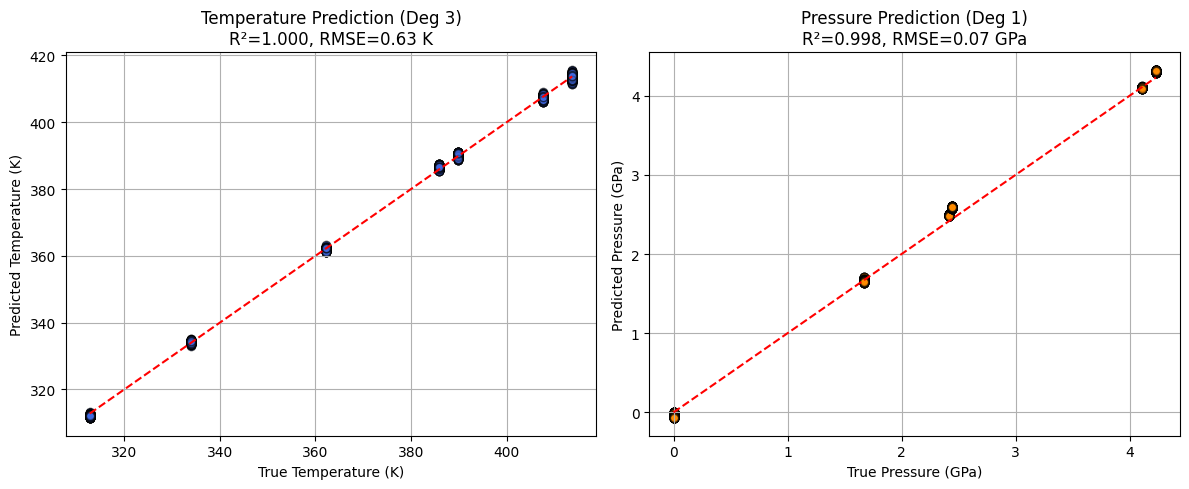

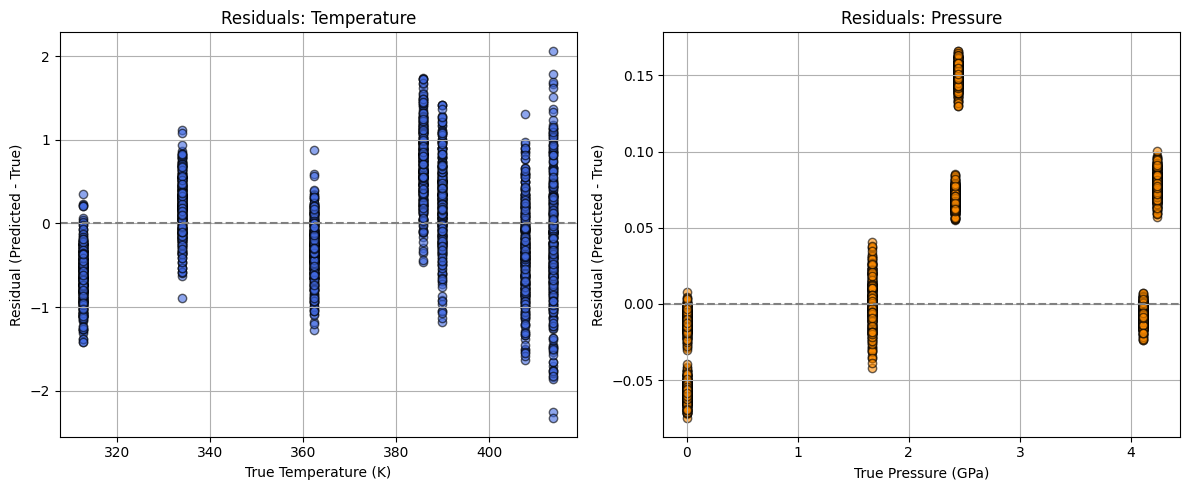

In [13]:
# --- Module 3.0: Validation: True vs. Predicted T and P Scatters and Residuals ---

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

def validate_regression(ld_model, scaler, degree, val_spectra, val_labels, 
                        train_ld1_means, train_labels, label, unit):
    """
    Validate polynomial regression using LD1 means.
    
    Args:
        ld_model: Trained LDA model.
        scaler: StandardScaler used on training data.
        degree: Polynomial degree to use.
        val_spectra: Validation spectra (samples x features).
        val_labels: Ground truth labels (per condition).
        train_ld1_means: LD1 means from training (used as regressor).
        train_labels: True training labels for regression.
        label: 'Temperature' or 'Pressure'.
        unit: Units (e.g., 'K', 'GPa').
    """
    spectra_per_condition = 350
    scaled_val = scaler.transform(val_spectra)
    ld1_val = ld_model.transform(scaled_val)[:, 0]

    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(train_ld1_means.reshape(-1, 1))
    model = LinearRegression().fit(X_train_poly, train_labels)

    X_val_poly = poly.transform(ld1_val.reshape(-1, 1))
    val_preds = model.predict(X_val_poly)

    val_labels_expanded = np.repeat(val_labels, spectra_per_condition)
    
    rmse = np.sqrt(mean_squared_error(val_labels_expanded, val_preds))
    r2 = r2_score(val_labels_expanded, val_preds)

    return val_labels_expanded, val_preds, rmse, r2


# --- Choose degrees for regression ---
T_degree = 3
P_degree = 1

# --- Run both regressions ---
val_T_true, val_T_pred, rmse_T, r2_T = validate_regression(
    LDA_T, scaler, T_degree, transposed_validation_spectra, T_validating_labels,
    LD1_T_means, T_training_labels, "Temperature", "K"
)

val_P_true, val_P_pred, rmse_P, r2_P = validate_regression(
    LDA_P, scaler, P_degree, transposed_validation_spectra, P_validating_labels,
    LD1_P_means, P_training_labels, "Pressure", "GPa"
)

# --- Plot both side by side ---
plt.figure(figsize=(12, 5))

# Temperature Plot
plt.subplot(1, 2, 1)
plt.scatter(val_T_true, val_T_pred, alpha=0.6, color='royalblue', edgecolor='k')
lims = [val_T_true.min(), val_T_true.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel("True Temperature (K)")
plt.ylabel("Predicted Temperature (K)")
plt.title(f"Temperature Prediction (Deg {T_degree})\nR²={r2_T:.3f}, RMSE={rmse_T:.2f} K")
plt.grid(True)

# Pressure Plot
plt.subplot(1, 2, 2)
plt.scatter(val_P_true, val_P_pred, alpha=0.6, color='darkorange', edgecolor='k')
lims = [val_P_true.min(), val_P_true.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel("True Pressure (GPa)")
plt.ylabel("Predicted Pressure (GPa)")
plt.title(f"Pressure Prediction (Deg {P_degree})\nR²={r2_P:.3f}, RMSE={rmse_P:.2f} GPa")
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Plot residuals side by side ---
plt.figure(figsize=(12, 5))

# Temperature Residuals
plt.subplot(1, 2, 1)
residuals_T = val_T_pred - val_T_true
plt.scatter(val_T_true, residuals_T, alpha=0.6, color='royalblue', edgecolor='k')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("True Temperature (K)")
plt.ylabel("Residual (Predicted - True)")
plt.title("Residuals: Temperature")
plt.grid(True)

# Pressure Residuals
plt.subplot(1, 2, 2)
residuals_P = val_P_pred - val_P_true
plt.scatter(val_P_true, residuals_P, alpha=0.6, color='darkorange', edgecolor='k')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("True Pressure (GPa)")
plt.ylabel("Residual (Predicted - True)")
plt.title("Residuals: Pressure")
plt.grid(True)

plt.tight_layout()
plt.show()

EXPORT: True vs. Predicted Scatters and Residuals 

# --- Export True vs. Predicted Scatters and Residuals ---

export_dir = Path(r"C:\\Users\\NP.5066655\\OneDrive - UAM\\Escritorio\\Harnessing CS_Ruby\\Data analysis\\LDA and PCA\\Code and chekcpoints\\Exports_LDA Resolution Test")

# Temperature
val_T_df = pd.DataFrame({
    "True Temperature (K)": val_T_true,
    "Predicted Temperature (K)": val_T_pred,
    "Residual (K)": residuals_T
})
val_T_df.to_csv(export_dir / "Delta 1 K_LD1-T Validation_690-700_Cubic.csv", index=False)

# Pressure
val_P_df = pd.DataFrame({
    "True Pressure (GPa)": val_P_true,
    "Predicted Pressure (GPa)": val_P_pred,
    "Residual (GPa)": residuals_P
})
val_P_df.to_csv(export_dir / "Delta 1 K_LD1-P Validation_690-700_Linear.csv", index=False)

print("✅ Validation results and residuals exported as CSV.")

EXPORT: Mean and Std LD1-P and LD1-P Scatters for Validation Dataset

# === Module X.Y — LD1-T / LD1-P Means ± Std on VALIDATION (mirrors Module 2.3) ===
import numpy as np
import pandas as pd
from pathlib import Path

# --- Config ---
spectra_per_block = 350
n_blocks = 7
OUT_DIR = r"C:\Users\NP.5066655\OneDrive - UAM\Escritorio\Polishing LDA\Code and chekcpoints\FINAL LDA_EXPORTS"
OUT_FILE = "Validation_LD1_TP_means_stds.csv"

# --- Scale the validation spectra (rows = spectra, cols = features) ---
# Uses variables already in your notebook:
# - transposed_validation_spectra (rows = spectra)
# - scaler (fit on training)
scaled_validation = scaler.transform(transposed_validation_spectra)

# --- Project onto LDA axes; take LD1 (column 0) ---
# Uses LDA_T and LDA_P already defined earlier
LD_T_projection_val = LDA_T.transform(scaled_validation)   # shape: (n_val, n_components)
LD_P_projection_val = LDA_P.transform(scaled_validation)   # shape: (n_val, n_components)

# --- Compute LD1 statistics per validation block (mirroring Module 2.3 style) ---
LD1_T_means_val, LD1_T_stds_val = [], []
LD1_P_means_val, LD1_P_stds_val = [], []

n_val = LD_T_projection_val.shape[0]
expected = spectra_per_block * n_blocks
n_to_use = min(n_val, expected)

for i in range(n_blocks):
    start = i * spectra_per_block
    end = min(start + spectra_per_block, n_to_use)
    if start >= n_to_use:
        break

    ld1_t_vals = LD_T_projection_val[start:end, 0]
    ld1_p_vals = LD_P_projection_val[start:end, 0]

    # Mirror Module 2.3: use np.mean and np.std (population std, no ddof change)
    LD1_T_means_val.append(np.mean(ld1_t_vals))
    LD1_T_stds_val.append(np.std(ld1_t_vals))

    LD1_P_means_val.append(np.mean(ld1_p_vals))
    LD1_P_stds_val.append(np.std(ld1_p_vals))

LD1_T_means_val = np.array(LD1_T_means_val)
LD1_T_stds_val  = np.array(LD1_T_stds_val)
LD1_P_means_val = np.array(LD1_P_means_val)
LD1_P_stds_val  = np.array(LD1_P_stds_val)

# --- Assemble tidy table ---
blocks = np.arange(1, len(LD1_T_means_val) + 1)
df_out = pd.DataFrame({
    "Block": blocks,
    "N_spectra": [min(spectra_per_block, n_to_use - (b-1)*spectra_per_block) for b in blocks],
    "LD1-T_mean": LD1_T_means_val,
    "LD1-T_std":  LD1_T_stds_val,
    "LD1-P_mean": LD1_P_means_val,
    "LD1-P_std":  LD1_P_stds_val,
})

# --- Export CSV ---
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
out_path = Path(OUT_DIR) / OUT_FILE
df_out.to_csv(out_path, index=False)
print(f"✅ Exported validation LD1-T/LD1-P means & stds ({len(blocks)} blocks) to:\n{out_path}")

MODULE 3.1: Violin Plots

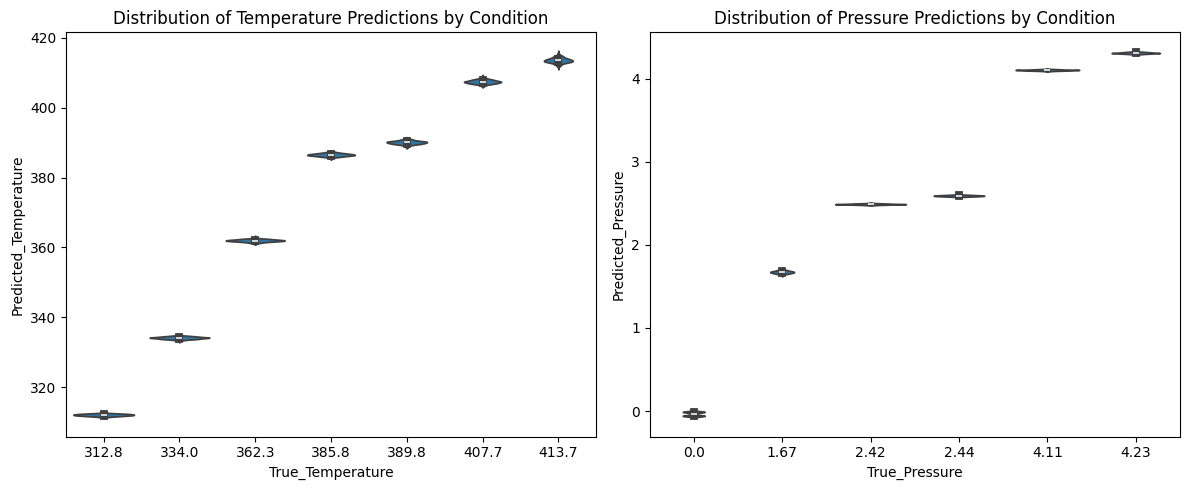

In [14]:
#----- Module 3.1: Violin Plots

import seaborn as sns
import pandas as pd

# Create DataFrames for violin plotting
df_T = pd.DataFrame({
    'True_Temperature': np.repeat(T_validating_labels, len(transposed_validation_spectra) // len(T_validating_labels)),
    'Predicted_Temperature': val_T_pred
})

df_P = pd.DataFrame({
    'True_Pressure': np.repeat(P_validating_labels, len(transposed_validation_spectra) // len(P_validating_labels)),
    'Predicted_Pressure': val_P_pred
})

# Violin plot: Temperature
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x='True_Temperature', y='Predicted_Temperature', data=df_T)
plt.title("Distribution of Temperature Predictions by Condition")

# Violin plot: Pressure
plt.subplot(1, 2, 2)
sns.violinplot(x='True_Pressure', y='Predicted_Pressure', data=df_P)
plt.title("Distribution of Pressure Predictions by Condition")

plt.tight_layout()
plt.show()

MODULE 3.2: Data Leakage Audit

In [15]:
# --- Module 3.2: Data Leakage Audit ---

import numpy as np
import hashlib

def hash_array(arr):
    """Create a SHA256 hash of a NumPy array (used for comparing spectra)."""
    return hashlib.sha256(arr).hexdigest()

def check_data_leakage(transposed_training_spectra, transposed_validation_spectra, 
                       scaler, lda_T, lda_P, train_ld1_means, T_training_labels, P_training_labels):
    print("\n🔍 DATA LEAKAGE AUDIT ------------------------------------")

    # 1. Check for exact spectrum overlap
    train_hashes = set([hash_array(spectrum) for spectrum in transposed_training_spectra])
    val_hashes = set([hash_array(spectrum) for spectrum in transposed_validation_spectra])
    shared = train_hashes.intersection(val_hashes)
    print(f"🧬 Spectral Overlap: {len(shared)} spectra shared between training and validation sets.")
    if shared:
        print("🚨 Potential data leakage: Validation spectra reused in training!")
    else:
        print("✅ Spectral sets are disjoint.")

    # 2. Confirm scaler was only fit on training data
    try:
        dummy_scaled_val = scaler.transform(transposed_validation_spectra)
        print("✅ Scaler used on validation data (not fit).")
    except Exception as e:
        print(f"🚨 Scaler issue: {e}")

    # 3. Confirm LDA projections were not used improperly
    if hasattr(lda_T, 'classes_') and hasattr(lda_P, 'classes_'):
        print("✅ LDA models trained before validation.")
    else:
        print("🚨 LDA model may not be trained correctly.")

    # 4. Ensure regression was trained only on training-derived LD1 means
    if len(train_ld1_means) == len(T_training_labels):
        print("✅ Temperature regression training based on correct LD1 stats.")
    else:
        print("🚨 Check: LD1_T_means and T_training_labels mismatch.")

    if len(train_ld1_means) == len(P_training_labels):
        print("✅ Pressure regression training based on correct LD1 stats.")
    else:
        print("🚨 Check: LD1_P_means and P_training_labels mismatch.")

    print("✅ Data Leakage Audit Completed.\n")

# --- Run the audit (put this at the end of your notebook) ---
check_data_leakage(
    transposed_training_spectra,
    transposed_validation_spectra,
    scaler,
    LDA_T,
    LDA_P,
    LD1_T_means,  # also works for pressure
    T_training_labels,
    P_training_labels
)


🔍 DATA LEAKAGE AUDIT ------------------------------------
🧬 Spectral Overlap: 0 spectra shared between training and validation sets.
✅ Spectral sets are disjoint.
✅ Scaler used on validation data (not fit).
✅ LDA models trained before validation.
✅ Temperature regression training based on correct LD1 stats.
✅ Pressure regression training based on correct LD1 stats.
✅ Data Leakage Audit Completed.



MODULE 4.0: Exporting selected training scaled spectra

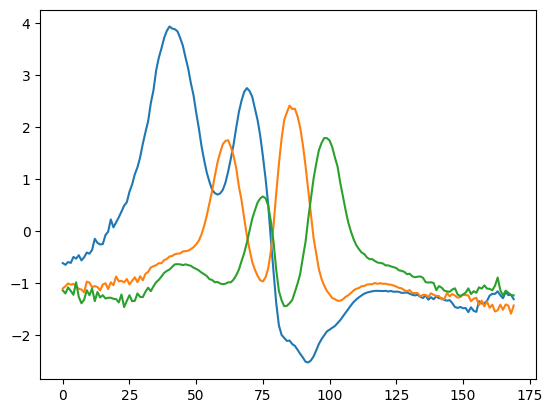

In [16]:
# Visualization of selected spectra from the dataset
# Plot sample normalized, scaled spectra

plt.plot(scaled_training_spectra[0], label=f"Spectrum")
plt.plot(scaled_training_spectra[700], label=f"Spectrum")
plt.plot(scaled_training_spectra[1400], label=f"Spectrum")

EXPORT: Scaled training spectra

# === EXPORT NORMALIZED, SCALED SPECTRA — blocks defined on RAW CSV (TRANSPOSED) ===
import numpy as np
import pandas as pd
from pathlib import Path

# --- CONFIG ---
BLOCK_SIZE = 350
BLOCKS_1_BASED = [5, 12, 26]  # 5th, 12th, 26th 350-spectra blocks (defined on RAW columns)
OUT_DIR = r"C:\Users\NP.5066655\OneDrive - UAM\Escritorio\Polishing LDA\Code and chekcpoints\FINAL LDA_EXPORTS"
BASE_NAME = "scaled_training_spectra"

# training_spectra_df: raw import (columns = spectra)
# scaled_training_spectra: standardized data (rows = spectra, columns = features)

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

n_spectra = training_spectra_df.shape[1]

def block_row_slice(block_k, block_size, total):
    """Return 0-based [start, stop) row indices for a 1-based block index."""
    start = (block_k - 1) * block_size
    stop = min(block_k * block_size, total)
    return start, stop

for k in BLOCKS_1_BASED:
    r0, r1 = block_row_slice(k, BLOCK_SIZE, n_spectra)
    if r0 >= n_spectra:
        print(f"Skipping block {k}: start {r0} >= total spectra {n_spectra}.")
        continue

    sel = scaled_training_spectra[r0:r1, :]  # rows = spectra, columns = features
    if sel.size == 0:
        print(f"Block {k}: slice empty; skipping.")
        continue

    # Transpose: spectra as columns, features as rows
    sel_T = sel.T

    out_path = Path(OUT_DIR) / f"{BASE_NAME}_block{k:02d}_rows{r0}-{r1-1}_TRANSPOSED.csv"
    pd.DataFrame(sel_T).to_csv(out_path, index=False, header=False)
    print(f"Exported block {k}: {sel_T.shape[1]} spectra × {sel_T.shape[0]} features (transposed) -> {out_path}")

EXPORT: Scaled validation spectra

# === EXPORT NORMALIZED, SCALED VALIDATION SPECTRA — blocks defined on RAW CSV (TRANSPOSED, NO HEADERS) ===
import numpy as np
import pandas as pd
from pathlib import Path

# --- CONFIG ---
BLOCK_SIZE = 350
BLOCKS_1_BASED = list(range(1, 8))  # 7 blocks of 350 spectra
OUT_DIR = r"C:\Users\NP.5066655\OneDrive - UAM\Escritorio\Polishing LDA\Code and chekcpoints\FINAL LDA_EXPORTS"
BASE_NAME = "scaled_validation_spectra"

# Variables present in your notebook:
# - validation_spectra_df  (raw: columns = spectra)
# - transposed_validation_spectra (rows = spectra, cols = features) 
# - scaler  (StandardScaler fit on training)
# We'll compute scaled validation on the fly:
scaled_validation = scaler.transform(transposed_validation_spectra)  # shape: [n_spectra, n_features]

# Number of spectra in the original validation CSV (columns = spectra)
n_spectra_val = validation_spectra_df.shape[1]

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

def block_row_slice(block_k, block_size, total):
    start = (block_k - 1) * block_size
    stop = min(block_k * block_size, total)
    return start, stop

for k in BLOCKS_1_BASED:
    r0, r1 = block_row_slice(k, BLOCK_SIZE, n_spectra_val)
    if r0 >= n_spectra_val:
        print(f"Skipping block {k}: start {r0} >= total validation spectra {n_spectra_val}.")
        continue

    sel = scaled_validation[r0:r1, :]  # rows=spectra, cols=features
    if sel.size == 0:
        print(f"Block {k}: slice empty; skipping.")
        continue

    # Transpose so each spectrum becomes a column (as Origin expects)
    sel_T = sel.T  # shape: (n_features, #spectra_in_block)

    out_path = Path(OUT_DIR) / f"{BASE_NAME}_block{k:02d}_rows{r0}-{r1-1}_TRANSPOSED.csv"
    pd.DataFrame(sel_T).to_csv(out_path, index=False, header=False)
    print(f"Exported VALIDATION block {k}: {sel_T.shape[1]} spectra × {sel_T.shape[0]} features -> {out_path}")